# Valuation Distribution by Position

After improving position matching (Position enum + case-mismatch fixes), regenerate valuations and check if the distribution across positions looks reasonable.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams["figure.figsize"] = (12, 6)

from fantasy_baseball_manager.db.connection import create_connection

conn = create_connection(Path("../data/fbm.db"))

In [2]:
# Load fresh valuations and the previous production run
fresh = pd.read_sql(
    """
    SELECT v.*, p.name_first || ' ' || p.name_last as player_name
    FROM valuation v JOIN player p ON v.player_id = p.id
    WHERE v.season = 2026 AND v.system = 'zar' AND v.version = 'fresh'
""",
    conn,
)

prod = pd.read_sql(
    """
    SELECT v.*, p.name_first || ' ' || p.name_last as player_name
    FROM valuation v JOIN player p ON v.player_id = p.id
    WHERE v.season = 2026 AND v.system = 'zar' AND v.version = 'production'
""",
    conn,
)

print(f"Fresh: {len(fresh)} valuations, Prod: {len(prod)} valuations")
print(f"\nFresh positions: {fresh['position'].value_counts().to_dict()}")
print(f"Prod positions:  {prod['position'].value_counts().to_dict()}")

Fresh: 941 valuations, Prod: 2394 valuations

Fresh positions: {'P': 345, 'RP': 254, 'OF': 125, '3B': 66, 'C': 44, '2B': 37, '1B': 31, 'SS': 22, 'UTIL': 17}
Prod positions:  {'p': 1059, 'util': 387, 'rp': 356, 'of': 237, '3b': 124, 'c': 95, '2b': 54, '1b': 52, 'ss': 30}


## Position distribution — draftable players (value > $1)

In [3]:
for label, df in [("Fresh (post position-fix)", fresh), ("Production (previous)", prod)]:
    draftable = df[df["value"] > 1.0]
    batters = draftable[draftable["player_type"] == "batter"]
    pitchers = draftable[draftable["player_type"] == "pitcher"]

    print(f"\n{'=' * 60}")
    print(f"{label}: {len(draftable)} draftable ({len(batters)} batters, {len(pitchers)} pitchers)")
    print(f"{'=' * 60}")

    pos_stats = (
        batters.groupby("position")
        .agg(
            count=("value", "size"),
            mean_val=("value", "mean"),
            median_val=("value", "median"),
            max_val=("value", "max"),
            total_val=("value", "sum"),
        )
        .round(1)
    )
    print("\nBatter positions:")
    print(pos_stats.sort_values("mean_val", ascending=False).to_string())

    pit_stats = (
        pitchers.groupby("position")
        .agg(
            count=("value", "size"),
            mean_val=("value", "mean"),
            median_val=("value", "median"),
            max_val=("value", "max"),
            total_val=("value", "sum"),
        )
        .round(1)
    )
    print("\nPitcher positions:")
    print(pit_stats.sort_values("mean_val", ascending=False).to_string())


Fresh (post position-fix): 153 draftable (90 batters, 63 pitchers)

Batter positions:
          count  mean_val  median_val  max_val  total_val
position                                                 
UTIL          1      33.6        33.6     33.6       33.6
OF           34      20.3        13.4     68.7      688.7
3B           12      18.2        17.1     44.6      218.1
1B           11      17.1        14.3     38.4      187.8
SS           11      15.6        11.3     37.0      171.8
C            12      13.5        11.2     39.5      161.9
2B            9      10.9         8.0     27.2       98.1

Pitcher positions:
          count  mean_val  median_val  max_val  total_val
position                                                 
P            39      29.9        21.6    116.4     1164.3
RP           24      16.5        13.4     49.7      395.7

Production (previous): 150 draftable (90 batters, 60 pitchers)

Batter positions:
          count  mean_val  median_val  max_val  total_va

## Top players by position

In [4]:
draftable = fresh[fresh["value"] > 1.0].copy()
for pos in ["C", "1B", "2B", "3B", "SS", "OF", "UTIL", "SP", "RP", "P"]:
    subset = draftable[draftable["position"] == pos].nlargest(5, "value")
    if len(subset) == 0:
        continue
    print(f"\n--- {pos} ---")
    print(subset[["player_name", "value", "rank"]].to_string(index=False))


--- C ---
      player_name  value  rank
      Cal Raleigh  39.48    19
William Contreras  26.34    38
     Iván Herrera  15.11    70
  Shea Langeliers  13.91    81
         Ben Rice  13.24    84

--- 1B ---
      player_name  value  rank
Vladimir Guerrero  38.39    20
  Freddie Freeman  25.08    42
     Bryce Harper  25.07    43
      Pete Alonso  22.23    52
       Matt Olson  21.04    57

--- 2B ---
   player_name  value  rank
   Ketel Marte  27.23    36
  Brice Turang  16.27    67
   José Altuve  12.35    89
Gleyber Torres   9.59   105
 Marcus Semien   8.04   113

--- 3B ---
    player_name  value  rank
   José Ramírez  44.63    14
  Jazz Chisholm  26.11    39
Junior Caminero  24.38    44
  Maikel García  22.33    51
  Manny Machado  20.58    60

--- SS ---
     player_name  value  rank
      Bobby Witt  37.00    23
 Elly De La Cruz  30.68    33
Gunnar Henderson  29.27    34
Francisco Lindor  21.04    56
       Zach Neto  14.16    79

--- OF ---
   player_name  value  rank
   Aaro

## Visualizations

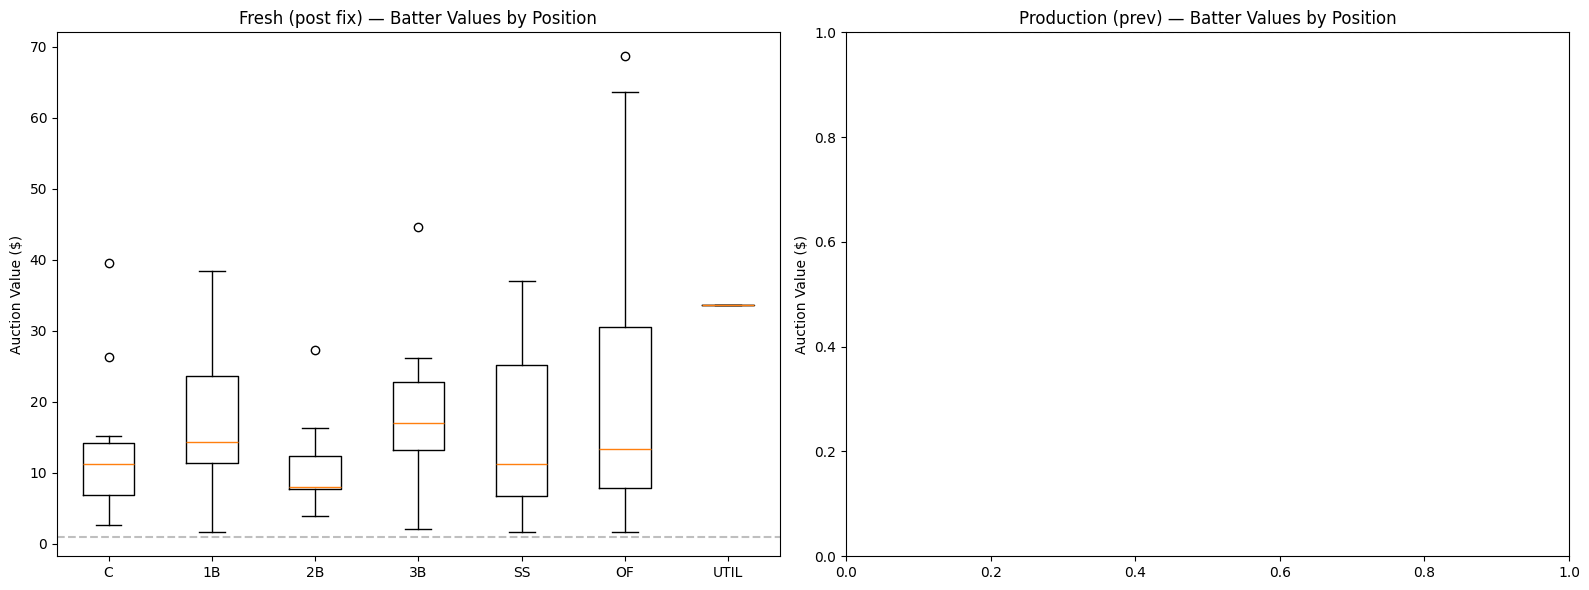

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
pos_order = ["C", "1B", "2B", "3B", "SS", "OF", "UTIL"]

for ax, (label, df) in zip(axes, [("Fresh (post fix)", fresh), ("Production (prev)", prod)]):
    batters = df[(df["value"] > 1.0) & (df["player_type"] == "batter")]
    data = [batters[batters["position"] == p]["value"].values for p in pos_order]
    valid = [(p, d) for p, d in zip(pos_order, data) if len(d) > 0]
    if valid:
        ax.boxplot([d for _, d in valid], tick_labels=[p for p, _ in valid])
    ax.set_title(f"{label} — Batter Values by Position")
    ax.set_ylabel("Auction Value ($)")
    ax.axhline(y=1, color="gray", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

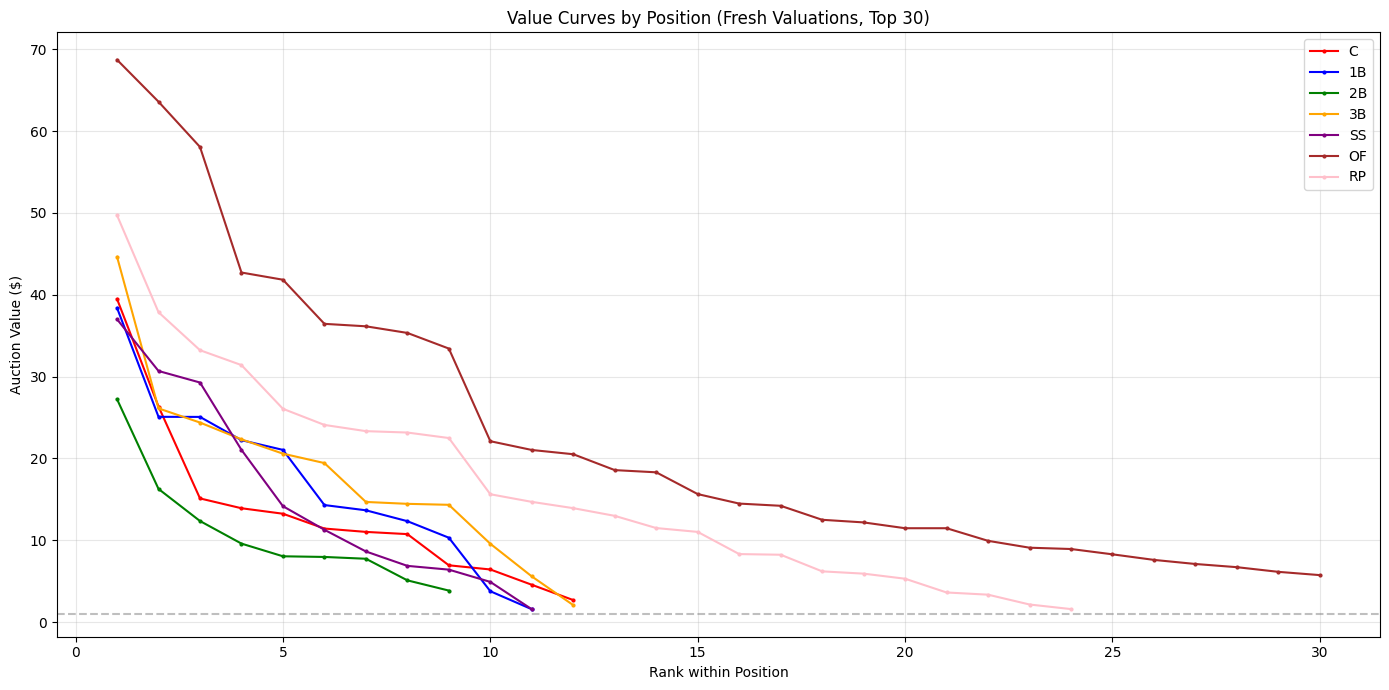

In [6]:
fig, ax = plt.subplots(figsize=(14, 7))
colors = {
    "C": "red",
    "1B": "blue",
    "2B": "green",
    "3B": "orange",
    "SS": "purple",
    "OF": "brown",
    "UTIL": "gray",
    "SP": "teal",
    "RP": "pink",
    "P": "olive",
}

draftable = fresh[fresh["value"] > 0].copy()
for pos in ["C", "1B", "2B", "3B", "SS", "OF", "SP", "RP"]:
    subset = draftable[draftable["position"] == pos].nlargest(30, "value")
    if len(subset) == 0:
        continue
    vals = subset["value"].values
    ax.plot(range(1, len(vals) + 1), vals, label=pos, color=colors.get(pos, "black"), marker=".", markersize=4)

ax.set_xlabel("Rank within Position")
ax.set_ylabel("Auction Value ($)")
ax.set_title("Value Curves by Position (Fresh Valuations, Top 30)")
ax.legend()
ax.axhline(y=1, color="gray", linestyle="--", alpha=0.5)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Budget allocation sanity check

In [7]:
draftable = fresh[fresh["value"] > 0]
bat_total = draftable[draftable["player_type"] == "batter"]["value"].sum()
pit_total = draftable[draftable["player_type"] == "pitcher"]["value"].sum()
print(f"Total batter value:  ${bat_total:,.0f}")
print(f"Total pitcher value: ${pit_total:,.0f}")
print(f"Grand total:         ${bat_total + pit_total:,.0f}")
print(f"Expected total:      $3,120")
print(
    f"\nBatter/Pitcher split: {bat_total / (bat_total + pit_total) * 100:.0f}% / {pit_total / (bat_total + pit_total) * 100:.0f}%"
)

print("\nTotal value by position:")
pos_totals = draftable.groupby("position")["value"].sum().sort_values(ascending=False).round(0)
print(pos_totals.to_string())

Total batter value:  $1,560
Total pitcher value: $1,560
Grand total:         $3,120
Expected total:      $3,120

Batter/Pitcher split: 50% / 50%

Total value by position:
position
P       1164.0
OF       689.0
RP       396.0
3B       218.0
1B       188.0
SS       172.0
C        162.0
2B        98.0
UTIL      34.0


## Position changes between prod and fresh

In [8]:
merged = fresh[["player_id", "player_name", "position", "value", "player_type"]].merge(
    prod[["player_id", "position", "value"]], on="player_id", suffixes=("_fresh", "_prod")
)
changed = merged[merged["position_fresh"] != merged["position_prod"]].copy()
changed["value_diff"] = changed["value_fresh"] - changed["value_prod"]
changed = changed.sort_values("value_fresh", ascending=False)

print(f"{len(changed)} players changed position out of {len(merged)} matched")
print(f"\nTop 20 position changes (by fresh value):")
print(
    changed[["player_name", "position_prod", "position_fresh", "value_prod", "value_fresh", "value_diff"]]
    .head(20)
    .to_string(index=False)
)

943 players changed position out of 943 matched

Top 20 position changes (by fresh value):
       player_name position_prod position_fresh  value_prod  value_fresh  value_diff
      Tarik Skubal             p              P      124.40       116.36       -8.04
       Paul Skenes             p              P       98.89        93.94       -4.95
   Garrett Crochet             p              P       94.63        90.59       -4.04
       Aaron Judge            of             OF       73.84        68.70       -5.14
         Juan Soto            of             OF       71.52        63.58       -7.94
        Chris Sale             p              P       64.63        61.85       -2.78
Cristopher Sánchez             p              P       61.10        59.00       -2.10
      Ronald Acuña            of             OF       64.07        58.05       -6.02
      Mason Miller            rp             RP       53.93        49.70       -4.23
      Jacob deGrom             p              P       50.91

## Draftable count comparison

In [9]:
print("Draftable players per position (value > $1):\n")
fresh_d = fresh[fresh["value"] > 1.0]
prod_d = prod[prod["value"] > 1.0]
fc = fresh_d.groupby("position")["value"].agg(["count", "mean", "min"]).round(1)
fc.columns = ["Fresh_count", "Fresh_avg", "Fresh_min"]
pc = prod_d.groupby("position")["value"].agg(["count", "mean", "min"]).round(1)
pc.columns = ["Prod_count", "Prod_avg", "Prod_min"]
combined = fc.join(pc, how="outer").fillna(0)
print(combined.to_string())

Draftable players per position (value > $1):

          Fresh_count  Fresh_avg  Fresh_min  Prod_count  Prod_avg  Prod_min
position                                                                   
1B               11.0       17.1        1.6         0.0       0.0       0.0
1b                0.0        0.0        0.0        11.0      17.8       2.4
2B                9.0       10.9        3.8         0.0       0.0       0.0
2b                0.0        0.0        0.0         9.0       9.9       1.3
3B               12.0       18.2        2.1         0.0       0.0       0.0
3b                0.0        0.0        0.0        12.0      16.3       4.6
C                12.0       13.5        2.7         0.0       0.0       0.0
OF               34.0       20.3        1.6         0.0       0.0       0.0
P                39.0       29.9        2.6         0.0       0.0       0.0
RP               24.0       16.5        1.6         0.0       0.0       0.0
SS               11.0       15.6        1.